<a href="https://colab.research.google.com/github/fynoeb/ImageProcessing/blob/main/Image_Processing_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

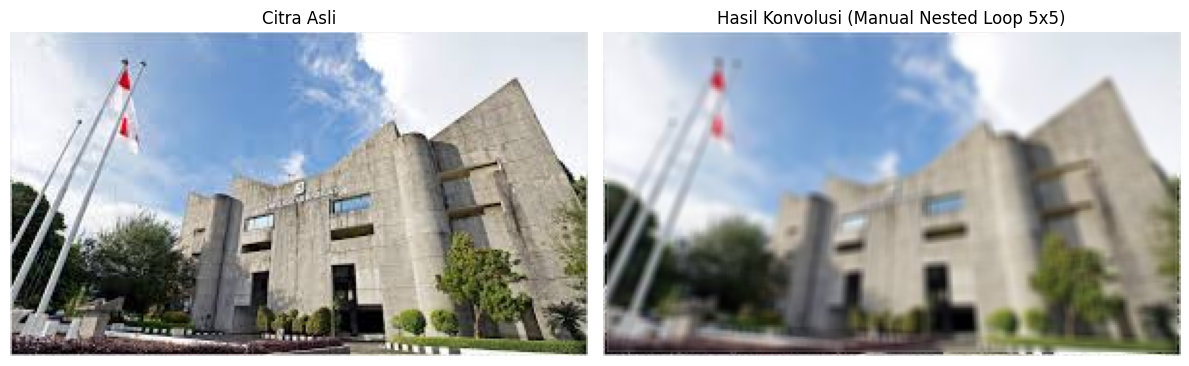

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def konvolusi_manual_super_strict(image_path):
    # Membaca citra
    img = mpimg.imread(image_path)

    # Konversi nilai piksel ke float (0.0 - 1.0)
    if img.dtype != 'float32' and img.dtype != 'float64':
        img = img.astype('float') / 255.0

    height = len(img)
    width = len(img[0])
    channels = len(img[0][0])

    # Menyiapkan wadah untuk citra hasil.
    # Copy nilai asli agar piksel pinggir (border) nilainya tetap sama seperti citra asal.
    output_img = img.copy()

    # Bobot untuk kernel rataan 5x5
    bobot = 1.0 / 25.0

    # ALGORITMA KONVOLUSI MANUAL
    # Loop mulai dari indeks 2 sampai batas-2 untuk mengabaikan border citra (karena kernel 5x5)
    for i in range(2, height - 2):
        for j in range(2, width - 2):
            for c in range(channels): # Eksekusi untuk setiap kanal warna (R, G, B)

                total_piksel = 0.0

                # Looping untuk area kernel 5x5 (dari -2 sampai +2)
                for ki in range(-2, 3):
                    for kj in range(-2, 3):
                        # Menjumlahkan piksel bertetangga
                        total_piksel += img[i + ki][j + kj][c]

                # Mengalikan total penjumlahan dengan bobot kernel, lalu simpan di pixel tengah
                output_img[i][j][c] = total_piksel * bobot

    # Memastikan nilai piksel tidak keluar batas 0-1
    for i in range(height):
        for j in range(width):
            for c in range(channels):
                if output_img[i][j][c] > 1.0:
                    output_img[i][j][c] = 1.0
                elif output_img[i][j][c] < 0.0:
                    output_img[i][j][c] = 0.0

    # Menampilkan hasil
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img)
    axes[0].set_title("Citra Asli")
    axes[0].axis('off')

    axes[1].imshow(output_img)
    axes[1].set_title("Hasil Konvolusi (Manual Nested Loop 5x5)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

konvolusi_manual_super_strict('citra_uji.jpg')